Imports

In [ ]:
import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from platform import python_version
import xgboost as xgb
import graphviz
from datetime import time
from datetime import datetime
from datetime import timedelta, date
import sklearn
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import LearningCurveDisplay
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import gc


print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")
print(f"XGBoost: v {xgb.__version__}")
print(f"LightGBM: v {lgb.__version__}")

python: v 3.10.12
Jupyter Notebook: v 7.4.7
numpy: v 1.25.2
pandas: v 2.3.3
seaborn: v 0.13.2
graphviz: v 0.21
matplotlib: v 3.7.2
sklearn: v 1.7.2
XGBoost: v 3.1.1
LightGBM: v 4.6.0


Import Data, Fill missing values and aggregate frames

In [ ]:
house_num = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21]
# Cluster 0
# house_num = [1, 2, 7, 12, 15, 17]
# Cluster 1
# house_num = [3, 5, 8, 9, 10, 13, 16, 21]
# Cluster 2
# house_num = [4, 6, 11, 18, 19, 20] 
df_hourlys = []
group_median = ()
def fill_with_group_median(row):
    if pd.isna(row['Volume']):
        return group_median.loc[(row['Month'], row['Weekday'], row['Hour'])]
    else:
        return row['Volume']


for selected in house_num:
    df = pd.read_csv(f"data/Refit/CLEAN_House{selected}.csv", header=0)
    df.rename(columns={'Time': 'Date'}, inplace=True)
    df.rename(columns={'Aggregate': 'Volume'}, inplace=True)
    df = df.dropna(subset=['Date', 'Volume'])
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.tz_localize(None)
    df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
    df = df.set_index('Date')
    appliance_cols = [col for col in df.columns if col.startswith('Appliance')]
    df['Sum_Appliances'] = df[appliance_cols].sum(axis=1)
    df['Difference'] = df['Sum_Appliances'] - df['Volume']
    print(f"House_{selected} - Difference: {df['Difference'].mean()}")
    hourly = df['Volume'].resample('1h').mean()
    df_hourly = hourly.to_frame(name='Volume')
    df_hourly['Hour'] = df_hourly.index.hour
    df_hourly['Weekday'] = df_hourly.index.weekday
    df_hourly['Month'] = df_hourly.index.month
    group_median = (
        df_hourly
        .groupby(['Month', 'Weekday', 'Hour'])['Volume']
        .median()
    )
    df_hourly['Volume'] = df_hourly.apply(fill_with_group_median, axis=1)
    df_hourlys.append(df_hourly)
    print(f"Processed House_{selected}")

for i in range(len(df_hourlys)):
    if i == 0:
        combined_df = df_hourlys[i]
    else:
        combined_df = pd.concat([combined_df, df_hourlys[i]], axis=0)

combined_df = combined_df.groupby(combined_df.index).agg({'Volume': 'sum'})
combined_df = combined_df.reset_index()
df_hourly = combined_df.copy()

del df_hourlys, combined_df, df, hourly
gc.collect()
print("CSVs read successfully.")



House_1 - Difference: -316.2512675272787
Processed House_1
CSVs read successfully.


Import Temperature Information

In [4]:
df_temps = pd.read_csv('data/Refit/hourly_Temp_data.csv')
df_temps.rename(columns={'date': 'Date'}, inplace=True)
df_temps.rename(columns={'temperature_2m': 'Temperature'}, inplace=True)
df_temps['Date'] = pd.to_datetime(df_temps['Date'], errors='coerce').dt.tz_localize(None)
df_temps = df_temps.set_index('Date')
df_temps = df_temps.asfreq("1h")
df_temps = df_temps.dropna(subset=['Temperature'])
df_temps['Temperature'] = pd.to_numeric(df_temps['Temperature'], errors='coerce')
df_hourly = pd.merge(df_hourly, df_temps, on='Date', how='left')

print("Temperature CSV read successfully.")
temp_index = df_hourly.set_index('Date')


Temperature CSV read successfully.


Feature Engineering

In [5]:
def add_date_scalar(df):
    df = df.copy()
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['Hour'] = df.Date.dt.hour
    df['Weekday'] = df.Date.dt.weekday  
    return df


def get_type_day(row):
    if row['Weekday'] in (5, 6): 
        return 1
    return 0

def add_type_day(df):
    df = df.copy()
    df['TypeDay'] = df.apply(get_type_day, axis=1)
    return df

# Add lag features while respecting no information after 10:00 AM previous day (offset = 2)
def prepare_data_with_lags(df, lag_start = 1, lag_end = 7, base_offset_days = 2, dropna = True):
    df = df.copy()
    df = add_type_day(df)

    df = df.set_index('Date')

    for k in range(lag_start, lag_end + 1):
        days_back = base_offset_days + (k - 1)
        df[f"lag-{k}"] = df['Volume'].shift(freq=f"{days_back}D")

    if dropna:
        lag_cols = [f"lag-{k}" for k in range(lag_start, lag_end + 1)]
        df = df.dropna(subset=lag_cols)

    df = df.reset_index()
    return df

# Builds a DataFrame with 24 hours
def get_weather_for_day(date_, temp_index):
    full_range = pd.date_range(date_, periods=25, freq='h')
    df_empty = pd.DataFrame({'Date': full_range})

    df_empty['Temperature'] = 0

    df = df_empty.tail(25).reset_index(drop=True)
    return df

Data preparation

In [6]:

df_general = add_date_scalar(df_hourly)

# Plot aggregate power consumption over time (Optional)
# plt.figure(figsize=(12, 6))
# plt.plot(df_general['Date'], df_general['Volume'], label='Aggregate Power Consumption')
# plt.xlabel('Date')
# plt.ylabel('Power Consumption (W)')
# plt.title('Aggregate Power Consumption Over Time')
# plt.legend()
# plt.show()

df_analytics = df_general.copy()
df_general = prepare_data_with_lags(df_general)

print("Data preparation completed.")


Data preparation completed.


Data Visualization helper functions

In [7]:
def plot_volume_over_time(df_hourly):
    plt.figure(figsize=(14, 5))
    plt.plot(df_hourly['Date'], df_hourly['Volume'])
    plt.title('Hourly Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_volume_and_temperature(df_hourly):
    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Volume', color='tab:blue')
    ax1.plot(df_hourly['Date'], df_hourly['Volume'], color='tab:blue', label='Volume')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Temperature', color='tab:red')  
    ax2.plot(df_hourly['Date'], df_hourly['Temperature'], color='tab:red', label='Temperature')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title('Volume and Temperature Over Time')
    fig.tight_layout()
    plt.show()
    plt.close()

def plot_avg_profile_by_hour(df_hourly):
    df = df_hourly.copy()
    df['Hour'] = df['Date'].dt.hour
    hourly_profile = df.groupby('Hour')['Volume'].mean()

    plt.figure(figsize=(8, 4))
    hourly_profile.plot(marker='o')
    plt.title('Average Daily Load Profile (by Hour)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_avg_volume_by_weekday(df_hourly):
    df = df_hourly.copy()
    df['Weekday'] = df['Date'].dt.weekday  # 0=Mon, 6=Sun
    weekday_profile = df.groupby('Weekday')['Volume'].mean()

    plt.figure(figsize=(8, 4))
    weekday_profile.plot(kind='bar')
    plt.title('Average Volume by Weekday')
    plt.xlabel('Weekday (0=Mon)')
    plt.ylabel('Average Volume')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_avg_volume_by_typeday(df_general):
    df = df_general.copy()
    if 'TypeDay' not in df.columns:
        df = add_type_day(df)

    typeday_profile = df.groupby('TypeDay')['Volume'].mean()

    plt.figure(figsize=(6, 4))
    typeday_profile.plot(kind='bar')
    plt.title('Average Volume by TypeDay')
    plt.xlabel('TypeDay')
    plt.ylabel('Average Volume')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_volume_vs_temperature(df_hourly):
    df = df_hourly.copy()
    df = df.dropna(subset=['Temperature', 'Volume'])

    plt.figure(figsize=(6, 4))
    plt.scatter(df['Temperature'], df['Volume'], alpha=0.3)
    plt.xlim(0, 25)
    plt.ylim(-500, 6000)
    plt.title('Volume vs Temperature')
    plt.xlabel('Temperature')
    plt.ylabel('Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_acf_pacf_of_series(df_hourly, max_lags_hours=24*7):
    series = df_hourly['Volume'].dropna()

    plt.figure(figsize=(10, 4))
    plot_acf(series, lags=max_lags_hours)
    plt.title('ACF of Volume')
    plt.tight_layout()
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 4))
    plot_pacf(series, lags=max_lags_hours)
    plt.title('PACF of Volume')
    plt.tight_layout()
    plt.show()
    plt.close()

Data visualization

In [8]:
# for i in range(len(df_analytics)):
#     num = house_num[i]
#     print(f"Generating plots for House_{num}:\n")
#     plot_volume_over_time(df_analytics[i])
#     plot_avg_profile_by_hour(df_analytics[i])
#     plot_avg_volume_by_weekday(df_analytics[i])
#     plot_avg_volume_by_typeday(df_analytics[i])
#     plot_volume_vs_temperature(df_analytics[i])
#     plot_volume_and_temperature(df_analytics[i])
#     plot_acf_pacf_of_series(df_analytics[i])
#     print("\n---------------------------------\n")

Training Function

In [9]:
def train_xgb_up_to_cutoff(df_general, target_day, max_depth = 6):
    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    df_train = df_general[df_general.Date <= cutoff_dt].copy()

    lag_cols = [c for c in df_train.columns if c.startswith("lag-")]
    df_train = df_train.dropna(subset=lag_cols + ['Volume'])

    X_train = df_train.drop(columns=['Date', 'Volume'])
    y_train = df_train['Volume']

    model = xgb.XGBRegressor(
        device='cpu',
        n_estimators=200,
        max_depth=max_depth, 
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=0.8
    )
    model.fit(X_train, y_train)
    return model


Main function to train the model and make predictions

In [10]:
# Predicts all 24 hours of target_day, using only data up to previous day at 10:00
# This function parameters are:
# - df_general: The general dataframe containing the data.
# - temp_index: The temperature index for the location.
# - target_day: The day for which to make predictions.
# - max_depth: The maximum depth for the model.
# - model: The trained model to use for predictions
def predict_day_hourly(df_general, temp_index, target_day, max_depth = 6, model=None):
    
    if model is None:
        print("Training new model...")
        model = train_xgb_up_to_cutoff(df_general, target_day, max_depth)

    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    # Base prediction frame
    df_pred_base = get_weather_for_day(target_day, temp_index)
    df_pred_base = add_date_scalar(df_pred_base)


    # for index, row in df_pred_base.iterrows():
    #     print(f"Row {index}: {row.to_dict()}")


    df_hist_for_lags = df_general[df_general.Date <= cutoff_dt].copy()
    # print(df_hist_for_lags)
    df_for_lags = pd.concat([df_hist_for_lags, df_pred_base], ignore_index=True)
    df_for_lags = df_for_lags.sort_values('Date').drop_duplicates(subset=['Date'])
    df_for_lags = prepare_data_with_lags(df_for_lags, lag_start=1, lag_end=7, base_offset_days=2, dropna=False)
    # print(df_for_lags)
    
    # for index, row in df_for_lags.iterrows():
    #     print(f"Row {index}: {row.to_dict()}")

    mask_target = df_for_lags['Date'].dt.date == target_day
    df_pred_features = df_for_lags.loc[mask_target].copy()
    # df_pred_features = pd.concat([df_pred_features,
    #                               df_for_lags[df_for_lags['Date'] == datetime.combine(target_day + timedelta(days=1), time(hour=0))]],
    #                              ignore_index=True)
   

    
    lag_cols = [c for c in df_pred_features.columns if c.startswith("lag-")]
    df_pred_features = df_pred_features.dropna(subset=lag_cols)
    # print(df_pred_features)


    # Prediction
    X_pred = df_pred_features.drop(columns=['Date', 'Volume'], errors='ignore')
    df_pred_features['Predicted'] = model.predict(X_pred)
    df_result = df_pred_features[['Date', 'Predicted']].sort_values('Date').reset_index(drop=True)
    
    return df_result


Helper functions to plot permutation importance and learning curve

In [11]:
# This functions parameters are:
# - model: The trained machine learning model for which permutation importance will be calculated and plotted.
# - X_train: The feature data used for training the model.
# - y_train: The target variable corresponding to the feature data.
# - n_repeats: The number of times to permute a feature.
def plot_permutation_importance(model, X_train, y_train, n_repeats=5):
    result = permutation_importance(
        model,
        X_train,
        y_train,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    plt.figure(figsize=(8, max(4, 0.4 * len(perm_df.head(20)))))
    plt.barh(perm_df.head(20)['feature'], perm_df.head(20)['importance_mean'])
    plt.gca().invert_yaxis()
    plt.xlabel('Permutation Importance (mean drop in score)')
    plt.title('Permutation Feature Importance')
    plt.tight_layout()
    plt.show()

    return perm_df

# function to plot learning curve
# This functions parameters are:
# - model: The machine learning model for which the learning curve will be plotted.
# - X: The feature data used for training the model.
# - y: The target variable corresponding to the feature data.
# - title: The title for the learning curve plot.
def plot_learning_curve(model, X, y, title="Learning Curve"):
    plt.figure(figsize=(10, 6))
    LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=2,
        n_jobs=-1,
        scoring='neg_mean_absolute_error'
    )
    plt.grid()
    plt.show()


Tuning Functions for XGBoost, LightGBM and Random Forest

In [12]:
# This function trains the model on data up to a specified cutoff date (previous day at 10:00 AM) and evaluates it using the specified scoring metric. The function returns the best model and the grid search results.
# The function takes the following parameters:
# - df_general: The input DataFrame containing the data.
# - target_day: The target day for which the model will be trained up to the cutoff date.
# - param_grid: A dictionary specifying the hyperparameters to be tuned and their respective values. If None, a default grid will be used.
# - cv_splits: The number of splits for time series cross-validation.
# - test_size: The number of samples to include in the test set for each split.
# - n_jobs: The number of jobs to run in parallel for grid search.
# - verbose: The verbosity level for grid search output.
# - scoring: The scoring metric to use for evaluating the models during grid search.
def tune_xgb_up_to_cutoff(
    df_general,
    target_day,
    param_grid=None,
    cv_splits=5,
    test_size=336,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error'
):

    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    df_train = df_general[df_general.Date <= cutoff_dt].copy()

    lag_cols = [c for c in df_train.columns if c.startswith("lag-")]
    df_train = df_train.dropna(subset=lag_cols + ['Volume'])

    X_train = df_train.drop(columns=['Date', 'Volume'])
    y_train = df_train['Volume']

    if param_grid is None:
        param_grid = {
            "n_estimators": [200],
            "max_depth": [4, 6, 8, 10],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        }

    base_model = xgb.XGBRegressor(
        device="cpu",
        n_jobs=n_jobs          
    )

    tscv = TimeSeriesSplit(n_splits=cv_splits, test_size=test_size)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=verbose
    )

    grid_search.fit(X_train, y_train)

    # plot_learning_curve(grid_search.best_estimator_, X_train, y_train)
    # plot_permutation_importance(grid_search.best_estimator_, X_train, y_train)

    print("Best parameters found:", grid_search.best_params_)
    print(f"Best CV {scoring}:", grid_search.best_score_)

    best_model = grid_search.best_estimator_
    return best_model, grid_search

# This function is similar to the tune_xgb_up_to_cutoff function but is designed for tuning a LightGBM model instead of XGBoost.
# The function takes the following parameters:
# - df_general: The input DataFrame containing the data.
# - target_day: The target day for which the model will be trained up to the cutoff date.
# - param_grid: A dictionary specifying the hyperparameters to be tuned and their respective values. If None, a default grid will be used.
# - cv_splits: The number of splits for time series cross-validation.
# - test_size: The number of samples to include in the test set for each split.
# - n_jobs: The number of jobs to run in parallel for grid search.
# - verbose: The verbosity level for grid search output.
# - scoring: The scoring metric to use for evaluating the models during grid search.
def tune_gbm_up_to_cutoff(
    df_general,
    target_day,
    param_grid=None,
    cv_splits=5,
    test_size=336,
    n_jobs=2,
    verbose=1,
    scoring='neg_mean_absolute_error'
):

    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    df_train = df_general[df_general.Date <= cutoff_dt].copy()

    lag_cols = [c for c in df_train.columns if c.startswith("lag-")]
    df_train = df_train.dropna(subset=lag_cols + ['Volume'])

    X_train = df_train.drop(columns=['Date', 'Volume'])
    y_train = df_train['Volume']

    if param_grid is None:
        param_grid = {
            "num_leaves": [31],
            "max_depth": [4, 5, 6],
            "learning_rate": [0.05, 0.01],
            "n_estimators": [200],
            "min_child_samples": [20, 50, 100],
            "subsample": [0.6, 0.7],
            "colsample_bytree": [0.6, 0.7, 0.8]
        }

    base_model = lgb.LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_jobs=6,
        random_state=42,
        verbosity=-1
    )

    tscv = TimeSeriesSplit(n_splits=cv_splits, test_size=test_size)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=verbose
    )

    grid_search.fit(X_train, y_train)

    # plot_learning_curve(grid_search.best_estimator_, X_train, y_train)
    # plot_permutation_importance(grid_search.best_estimator_, X_train, y_train)

    print("Best parameters found:", grid_search.best_params_)
    print(f"Best CV {scoring}:", grid_search.best_score_)

    best_model = grid_search.best_estimator_
    return best_model, grid_search


# This function is similar to the tune_xgb_up_to_cutoff function but is designed for tuning a Random Forest model instead of XGBoost.
# The function takes the following parameters:
# - df_general: The input DataFrame containing the data.
# - target_day: The target day for which the model will be trained up to the cutoff date.
# - param_grid: A dictionary specifying the hyperparameters to be tuned and their respective values. If None, a default grid will be used.
# - cv_splits: The number of splits for time series cross-validation.
# - test_size: The number of samples to include in the test set for each split.
# - n_jobs: The number of jobs to run in parallel for grid search.
# - verbose: The verbosity level for grid search output.
# - scoring: The scoring metric to use for evaluating the models during grid search.
def tune_rf_up_to_cutoff(
    df_general,
    target_day,
    param_grid=None,
    cv_splits=5,
    test_size=336,
    n_jobs=2,
    verbose=1,
    scoring='neg_mean_absolute_error'
):

    prev_day = target_day - timedelta(days=1)
    cutoff_dt = datetime.combine(prev_day, time(hour=10))

    df_train = df_general[df_general.Date <= cutoff_dt].copy()

    lag_cols = [c for c in df_train.columns if c.startswith("lag-")]
    df_train = df_train.dropna(subset=lag_cols + ['Volume'])

    X_train = df_train.drop(columns=['Date', 'Volume'])
    y_train = df_train['Volume']

    if param_grid is None:
        param_grid = {
            'n_estimators': [200],
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }

    base_model = RandomForestRegressor(
        n_jobs=6,
        random_state=42
    )

    tscv = TimeSeriesSplit(n_splits=cv_splits, test_size=test_size)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=verbose
    )

    grid_search.fit(X_train, y_train)

    # plot_learning_curve(grid_search.best_estimator_, X_train, y_train)
    # plot_permutation_importance(grid_search.best_estimator_, X_train, y_train)

    print("Best parameters found:", grid_search.best_params_)
    print(f"Best CV {scoring}:", grid_search.best_score_)

    best_model = grid_search.best_estimator_
    return best_model, grid_search


Helper Functions for Residual Analysis

In [13]:
def plot_residuals_over_time(df_eval):
    plt.figure(figsize=(10, 4))
    plt.plot(df_eval['Date'], df_eval['Residual'], marker='o')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residuals Over Time')
    plt.xlabel('Date/Hour')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_residuals_by_hour_weekday_typeday(df_eval):
    df = df_eval.copy()
    df['Hour'] = df['Date'].dt.hour
    df['Weekday'] = df['Date'].dt.weekday

    if 'TypeDay' not in df.columns:
        df = add_type_day(add_date_scalar(df))  # assuming add_type_day uses Weekday
    
    # Mean residual by hour
    plt.figure(figsize=(8, 4))
    df.groupby('Hour')['Residual'].mean().plot(kind='bar')
    plt.title('Mean Residual by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Mean Residual')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Mean residual by weekday
    plt.figure(figsize=(8, 4))
    df.groupby('Weekday')['Residual'].mean().plot(kind='bar')
    plt.title('Mean Residual by Weekday')
    plt.xlabel('Weekday (0=Mon)')
    plt.ylabel('Mean Residual')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Mean residual by TypeDay
    if 'TypeDay' in df.columns:
        plt.figure(figsize=(6, 4))
        df.groupby('TypeDay')['Residual'].mean().plot(kind='bar')
        plt.title('Mean Residual by TypeDay')
        plt.xlabel('TypeDay')
        plt.ylabel('Mean Residual')
        plt.grid(axis='y')
        plt.tight_layout()
        plt.show()

def plot_residual_distribution(df_eval):
    resid = df_eval['Residual'].dropna()

    plt.figure(figsize=(6, 4))
    plt.hist(resid, bins=20, edgecolor='k', alpha=0.7)
    plt.title('Residual Histogram')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    stats.probplot(resid, dist="norm", plot=plt)
    plt.title('Q–Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

def plot_acf_of_residuals(df_eval, max_lags_hours=24*7):
    resid = df_eval['Residual'].dropna()

    plt.figure(figsize=(10, 4))
    plot_acf(resid, lags=max_lags_hours)
    plt.title('ACF of Residuals')
    plt.tight_layout()
    plt.show()



Main prediction Loop

In [14]:
train_date = date(2015, 4, 15)
days = 15

metrics_summary = []
meta_metrics = []
models = []
big_eval = pd.DataFrame()


print(f"Results for Houses :")
xgb_model, gs = tune_xgb_up_to_cutoff(df_general, train_date)
gbm_model, gs_gbm = tune_gbm_up_to_cutoff(df_general, train_date)
rf_model, gs_rf = tune_rf_up_to_cutoff(df_general, train_date)

models.append({
    'XGB_Model': xgb_model,
    'GBM_Model': gbm_model,
    'RF_Model': rf_model
})

for d in range(0, days):
    df_forecast_xgb = predict_day_hourly(df_general, temp_index, train_date + timedelta(days=d), model=xgb_model)
    df_forecast_gbm = predict_day_hourly(df_general, temp_index, train_date + timedelta(days=d), model=gbm_model)
    df_forecast_rf = predict_day_hourly(df_general, temp_index, train_date + timedelta(days=d), model=rf_model)
    
    # Combination of all three models predictions by average
    df_forecast = pd.DataFrame()
    df_forecast['Date'] = df_forecast_xgb['Date']
    df_forecast['Predicted'] = (df_forecast_xgb['Predicted'] + df_forecast_gbm['Predicted'] + df_forecast_rf['Predicted']) / 3
    df_actual = df_general[df_general['Date'].dt.date == (train_date + timedelta(days=d))][['Date', 'Volume']].reset_index(drop=True)
    df_eval = pd.merge(df_forecast, df_actual, on='Date', how='inner')
    df_eval['Residual'] = df_eval['Volume'] - df_eval['Predicted']
    df_eval['XGB_Predicted'] = df_forecast_xgb['Predicted']
    df_eval['GBM_Predicted'] = df_forecast_gbm['Predicted']
    df_eval['RF_Predicted'] = df_forecast_rf['Predicted']
    
    rmse = np.sqrt(np.mean((df_eval['Predicted'] - df_eval['Volume'])**2))
    mae = MAE(df_eval['Predicted'], df_eval['Volume'])
    mape = MAPE(df_eval['Predicted'], df_eval['Volume'])
    metrics_summary.append({
        'Date': train_date + timedelta(days=d),
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })
    big_eval = pd.concat([big_eval, df_eval], ignore_index=True)
    
    # Metrics and plot for each day (Optional)
    # print(f"  RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2%}")
    # plt.figure(figsize=(10, 6))
    # plt.plot(df_eval['Date'], df_eval['Volume'], label='Actual', marker='o')
    # plt.plot(df_eval['Date'], df_eval['Predicted'], label='Predicted', marker='x')
    # plt.xlabel('Date')
    # plt.ylabel('Volume')
    # plt.title(f'Actual vs Predicted Volume for {train_date + timedelta(days=d)}')
    # plt.legend()
    # plt.grid()
    # # plt.show()
    # plt.close()

# print(f"Metrics Summary for 30 Days Forecast for Houses:")
# for metrics in metrics_summary:
#     print(f"Date: {metrics['Date']} - RMSE: {metrics['RMSE']:.2f}, MAE: {metrics['MAE']:.2f}, MAPE: {metrics['MAPE']:.2%}")
# average_rmse = np.mean([m['RMSE'] for m in metrics_summary])
# average_mae = np.mean([m['MAE'] for m in metrics_summary])
# average_mape = np.mean([m['MAPE'] for m in metrics_summary])
# print(f"Average RMSE: {average_rmse:.2f}, Average MAE: {average_mae:.2f}, Average MAPE: {average_mape:.2%}")
# meta_metrics.append({
#     'Average_RMSE': average_rmse,
#     'Average_MAE': average_mae,
#     'Average_MAPE': average_mape
# })

# Metrics for each model separately
xgb_rmse = np.sqrt(np.mean((big_eval['XGB_Predicted'] - big_eval['Volume'])**2))
xgb_mae = MAE(big_eval['XGB_Predicted'], big_eval['Volume'])
xgb_mape = MAPE(big_eval['XGB_Predicted'], big_eval['Volume'])
print(f"XGB - Overall RMSE: {xgb_rmse:.2f}, Overall MAE: {xgb_mae:.2f}, Overall MAPE: {xgb_mape:.2%}")
gbm_rmse = np.sqrt(np.mean((big_eval['GBM_Predicted'] - big_eval['Volume'])**2))
gbm_mae = MAE(big_eval['GBM_Predicted'], big_eval['Volume'])
gbm_mape = MAPE(big_eval['GBM_Predicted'], big_eval['Volume'])
print(f"GBM - Overall RMSE: {gbm_rmse:.2f}, Overall MAE: {gbm_mae:.2f}, Overall MAPE: {gbm_mape:.2%}")
rf_rmse = np.sqrt(np.mean((big_eval['RF_Predicted'] - big_eval['Volume'])**2))
rf_mae = MAE(big_eval['RF_Predicted'], big_eval['Volume'])
rf_mape = MAPE(big_eval['RF_Predicted'], big_eval['Volume'])
print(f"RF - Overall RMSE: {rf_rmse:.2f}, Overall MAE: {rf_mae:.2f}, Overall MAPE: {rf_mape:.2%}")
metrics_summary = []

# Metrics and plot for aggregated actual vs predicted across all houses selected (Optional)
# overall_average_rmse = np.mean([m['Average_RMSE'] for m in meta_metrics])
# overall_average_mae = np.mean([m['Average_MAE'] for m in meta_metrics])
# overall_average_mape = np.mean([m['Average_MAPE'] for m in meta_metrics])
# print(f"Overall Average RMSE across all houses: {overall_average_rmse:.2f}, Overall Average MAE: {overall_average_mae:.2f}, Overall Average MAPE: {overall_average_mape:.2%}")


# plt.figure(figsize=(12, 6))
# plt.plot(big_eval['Date'], big_eval['Volume'], label='Actual', marker='o')
# plt.plot(big_eval['Date'], big_eval['Predicted'], label='Predicted', marker='x')
# plt.xlabel('Date')
# plt.ylabel('Volume')
# plt.title(f'Actual vs Predicted Volume for House_{selected}')
# plt.legend()
# plt.grid()
# plt.show()
# plt.close()

# Residual Analysis (Optional) 

# plot_residuals_over_time(big_eval)
# plot_residuals_by_hour_weekday_typeday(big_eval)
# plot_residual_distribution(big_eval)
# plot_acf_of_residuals(big_eval, max_lags_hours=24*14)

Results for Houses :
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
Best CV neg_mean_absolute_error: -257.6240206508104
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 100, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.6}
Best CV neg_mean_absolute_error: -249.4696597487194
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV neg_mean_absolute_error: -247.54667444763714
XGB - Overall RMSE: 405.85, Overall MAE: 282.39, Overall MAPE: 51.42%
GBM - Overall RMSE: 394.94, Overall MAE: 270.15, Overall MAPE: 51.97%
RF - Overall RMSE: 396.26, Overall MAE: 253.85, Overall MAPE: 50.90%


Save to file

In [ ]:
big_eval.to_csv('Predictions/Refit_forecasts_Combi_Agg_complete.csv', index=False)

Feature Importance (Optional)

For House_1 :

Feature importance for XGBoost model:


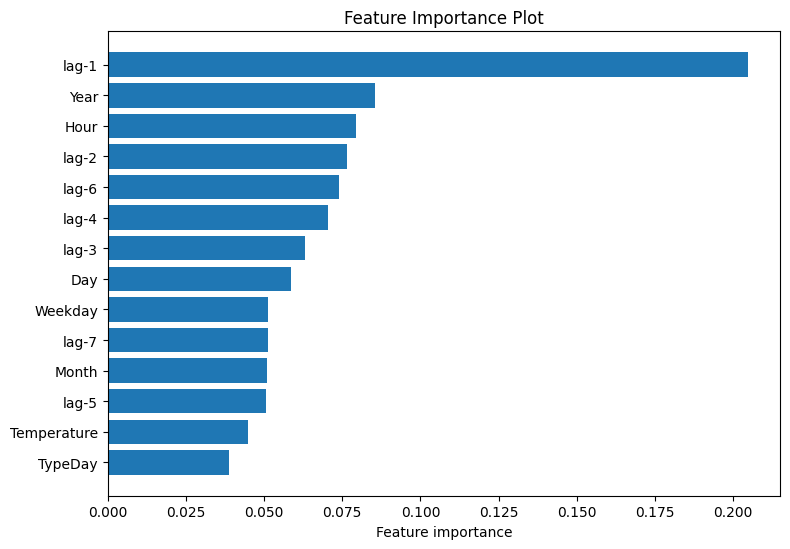


Feature importance for LightGBM model:


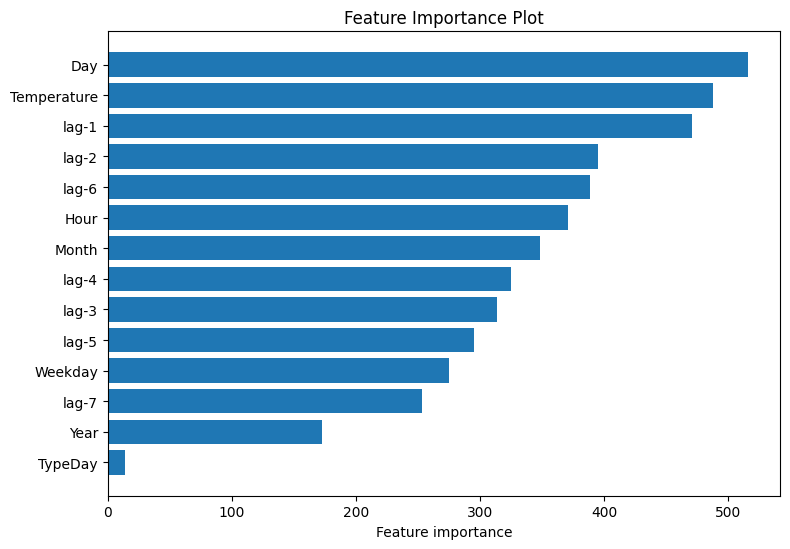


Feature importance for Random Forest model:


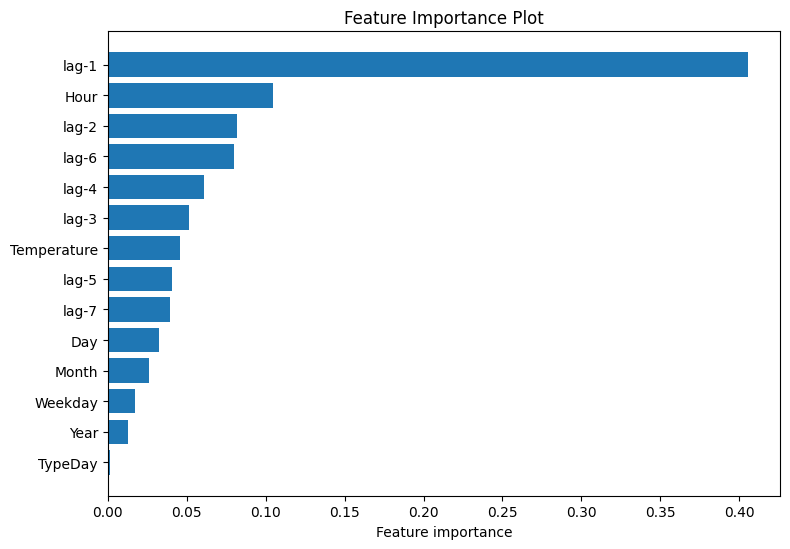

In [ ]:
# Function to plot feature importance for XGBoost model
# This function parameters are:
# - model: The trained XGBoost model for which feature importance will be plotted.
# - feature_names: A list of feature names corresponding to the features used in the model.
# - top_n: The number of top features to display in the plot.
def plot_feature_importance(model, feature_names, top_n):
    importances = model.feature_importances_
    fi = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    fi_top = fi.head(top_n)

    plt.figure(figsize=(8, max(4, 0.4 * len(fi_top))))
    plt.barh(fi_top['feature'], fi_top['importance'])
    plt.gca().invert_yaxis()
    plt.xlabel('Feature importance')
    plt.title('Feature Importance Plot')
    plt.tight_layout()
    plt.show()

    return fi

for selected in range(len(models)):
    print(f"For House_{house_num[selected]} :")
    xgb_model = models[selected]['XGB_Model']
    gbm_model = models[selected]['GBM_Model']
    rf_model = models[selected]['RF_Model']

    for model_name, model in zip(['XGBoost', 'LightGBM', 'Random Forest'], [xgb_model, gbm_model, rf_model]):
        print(f"\nFeature importance for {model_name} model:")
        fi_table = plot_feature_importance(
            model=model,
            feature_names=[col for col in df_general.columns if col not in ['Date', 'Volume']],
            top_n=20
        )
        fi_table.head()

